# Dexm Scene Simulation, Visualization & Camera Sensor

This notebook initializes the Dexm scene and solvers via `DexmBuilder` in a **side-by-side bimanual setup**, preloads and captures the simulation into a **GPU CUDA Graph** for accelerated execution, captures frames using the GPU raytraced **`SensorTiledCamera`**, and visualizes the scene in both **Viser** and as an **animated GIF / JPEG sequence**.

In [1]:
import sys
from pathlib import Path

# Ensure dexm package can be imported
ROOT_DIR = Path("..").resolve()
if str(ROOT_DIR / "src") not in sys.path:
    sys.path.insert(0, str(ROOT_DIR / "src"))

import newton
import numpy as np
import warp as wp
from PIL import Image
from IPython.display import Image as IPyImage, display
from dexm.builder import DexmBuilder

newton.use_coord_layout_targets = True

In [2]:
def make_viewer(name: str = "dexm_scene"):
    recording_path = Path("../_static/recordings") / f"{name}.viser"
    recording_path.parent.mkdir(parents=True, exist_ok=True)
    return newton.viewer.ViewerViser(
        verbose=False, record_to_viser=str(recording_path)
    )

## 1. Build Scene & Initialize Solvers + Camera Sensor
`DexmBuilder` sets up the MuJoCo + VBD coupled solver, forward kinematics, collision pipelines, and `SensorTiledCamera`.

### Camera Placement:
- **Position (`camera_pos`)**: `(0.0, 1.25, 0.65)` in front of the workspace at an elevated vantage point.
- **Look-At Target (`camera_target`)**: `(0.0, 0.35, 0.18)` looking back toward the robot arms, cube, and cable.
- **Field of View (`camera_fov`)**: `52.0°` (pinhole ray model at $800 \times 600$ resolution).

In [3]:
# Initialize Dexm scene with side-by-side arms and front-facing elevated camera
dexm = DexmBuilder(
    worlds_count=1,
    fps=30,
    sim_substeps=10,
    use_graph=True,
    arm_separation=0.80,
    cable_center=wp.vec3(0.0, 0.50, 0.40),
    cube_pos=wp.vec3(0.0, 0.50, 0.20),
    enable_camera=True,
    camera_pos=(0.0, 1.25, 0.65),
    camera_target=(0.0, 0.35, 0.18),
    camera_width=800,
    camera_height=600,
    camera_fov=52.0,
)
model = dexm.model

print(f"Bodies: {model.body_count}, Joints: {model.joint_count}, Shapes: {model.shape_count}")
print(f"Franka 1 bodies: {len(dexm.franka1_bodies)}, Franka 2 bodies: {len(dexm.franka2_bodies)}")
print(f"Cable bodies: {len(dexm.cable_bodies)}, Cube bodies: {len(dexm.cube_bodies)}")
print(f"CUDA Graph preloaded & captured: {dexm.graph is not None}")
print(f"SensorTiledCamera initialized: {dexm.camera_sensor is not None}")

Warp 1.16.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 5090" (31 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/run/.cache/warp/1.16.0
Module newton._src.geometry.inertia f54b3d2 load on device 'cuda:0' took 0.85 ms  (cached)
Module newton._src.utils.mesh 3a50b9a load on device 'cpu' took 0.90 ms  (cached)
Module warp._src.coloring 0a2f0aa load on device 'cpu' took 0.20 ms  (cached)
Module validate_and_correct_inertia_kernel_5e18b3cd 5e18b3c load on device 'cuda:0' took 0.31 ms  (cached)
Module newton._src.geometry.bvh cca3a6c load on device 'cuda:0' took 0.68 ms  (cached)
Module newton._src.solvers.coupled.model_view 399a588 load on device 'cuda:0' took 0.53 ms  (cached)
Module newton._src.solvers.coupled.solver_coupled c727aa4 load on device 'cuda:0' took 0.64 ms  (cached)
Module newton._src.solvers.mujoco.kernels 9bf0320 load on device 'cuda:0' took 7.26 ms  (cached)
Module mujoco_warp._src.i

## 2. Run Simulation, Record in Viser & Capture Camera Frames (1.5 - 3 Seconds)
Each frame, `dexm.step()` executes the CUDA graph accelerated physics substeps, and `dexm.render_camera()` fetches the real-time raytraced RGB camera sensor frame.

In [4]:
DURATION = 2.0  # seconds
FPS = dexm.fps
num_frames = int(FPS * DURATION)

# Setup Viser viewer
viewer = make_viewer("dexm_scene_sim")
viewer.set_model(model)
viewer.set_camera(wp.vec3(0.0, -1.2, 0.9), -20, 90)

camera_frames = []

# Capture frame 0
camera_frames.append(dexm.render_camera())

for frame in range(num_frames):
    # 1. Log current state to Viser
    viewer.begin_frame(dexm.sim_time)
    viewer.log_state(dexm.state_0)
    viewer.log_contacts(dexm.contacts, dexm.state_0)
    viewer.end_frame()

    # 2. Advance physics via GPU CUDA graph
    dexm.step()

    # 3. Capture camera sensor frame (RGB uint8 array)
    rgb_frame = dexm.render_camera()
    camera_frames.append(rgb_frame)

print(f"Simulation finished! Total frames captured: {len(camera_frames)}")
viewer

╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

Module newton._src.viewer.kernels 01f8575 load on device 'cuda:0' took 1.66 ms  (cached)
Module create_kernel__locals__render_megakernel_8a6e4b77 1de3abe load on device 'cuda:0' took 0.54 ms  (cached)
Simulation finished! Total frames captured: 61


## 3. View Camera Outputs (JPEG & Animated Sequence)
Save and display the initial and final camera frames as JPEG images, and play back the entire sequence as an animated GIF.

Saved JPEG frame: ../_static/renders/camera_frame_initial.jpg
Saved Animated GIF: ../_static/renders/camera_simulation.gif

--- Initial Camera View (JPEG) ---


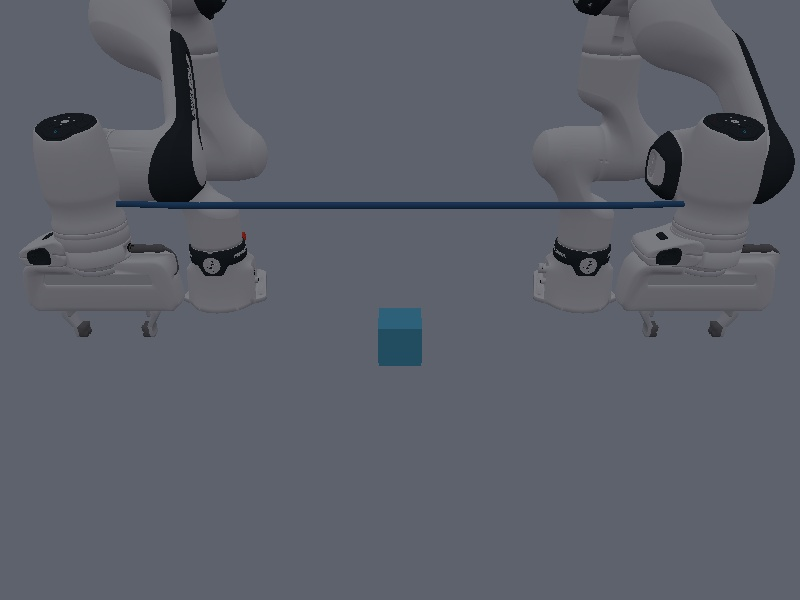


--- Final Settled Camera View (JPEG) ---


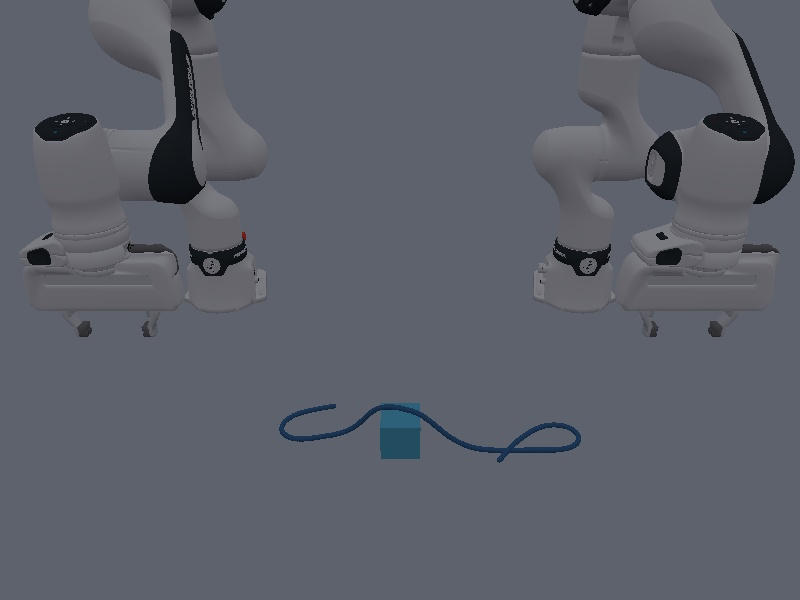


--- Animated Camera Sensor Video (GIF) ---


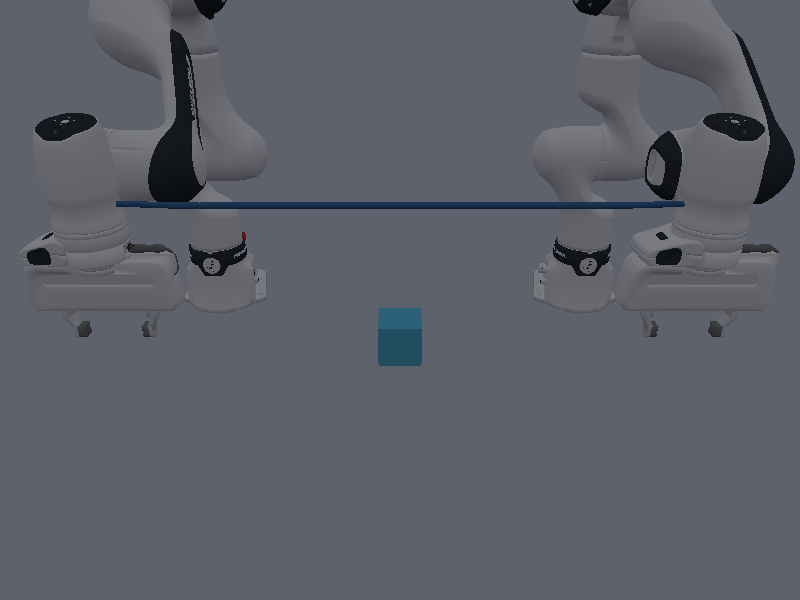

In [5]:
renders_dir = Path("../_static/renders")
renders_dir.mkdir(parents=True, exist_ok=True)

# Save initial and final frames as JPEG
initial_jpg_path = renders_dir / "camera_frame_initial.jpg"
final_jpg_path = renders_dir / "camera_frame_final.jpg"
Image.fromarray(camera_frames[0]).save(initial_jpg_path, quality=95)
Image.fromarray(camera_frames[-1]).save(final_jpg_path, quality=95)

# Save full sequence as animated GIF
gif_path = renders_dir / "camera_simulation.gif"
dexm.save_camera_animation(camera_frames, gif_path, fps=dexm.fps)

print(f"Saved JPEG frame: {initial_jpg_path}")
print(f"Saved Animated GIF: {gif_path}")

# Display the initial camera view JPEG
print("\n--- Initial Camera View (JPEG) ---")
display(IPyImage(filename=str(initial_jpg_path)))

# Display the final settled camera view JPEG
print("\n--- Final Settled Camera View (JPEG) ---")
display(IPyImage(filename=str(final_jpg_path)))

# Display the animated GIF playback sequence
print("\n--- Animated Camera Sensor Video (GIF) ---")
display(IPyImage(filename=str(gif_path)))